# 01 · Exploratory data analysis

What the labelled data looks like *as the model will see it*: read from `mart.training` (the same table the training code uses), so every observation here is about model inputs, not raw CSV.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
from fraudlake.config import get_settings
S = get_settings()
A = S.artifacts_dir
df = pd.read_parquet(A / "mart" / "training.parquet")
df["txn_ts"] = pd.to_datetime(df["txn_ts"])
print(f"{len(df):,} labelled transactions, {df.shape[1]} columns, fraud rate {df.is_fraud.mean():.3%}")

590,540 labelled transactions, 481 columns, fraud rate 3.499%


## Class balance and how it moves over time

The fraud rate is not constant. Anything that drifts this much over six months is a warning that a shuffled validation split will lie.

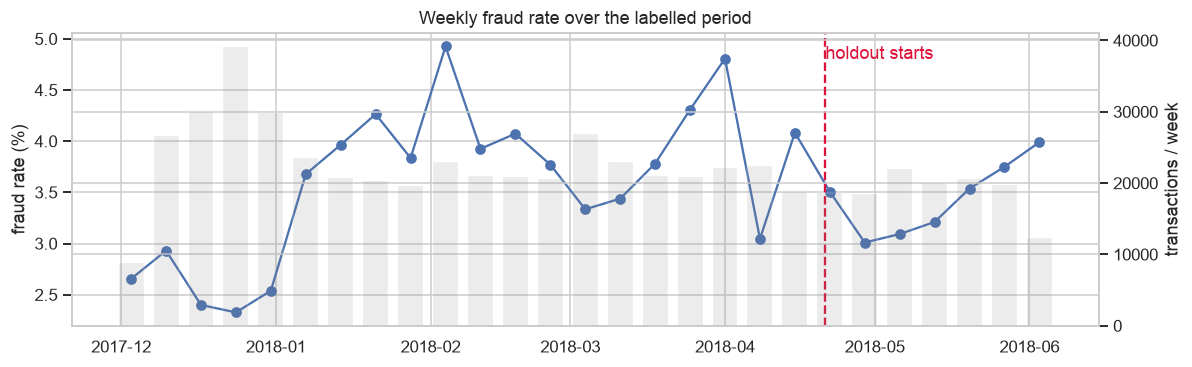

In [2]:
weekly = df.set_index("txn_ts").resample("W")["is_fraud"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(weekly.index, weekly["mean"] * 100, marker="o")
ax.set(ylabel="fraud rate (%)", title="Weekly fraud rate over the labelled period")
ax2 = ax.twinx(); ax2.bar(weekly.index, weekly["size"], width=5, alpha=0.15, color="gray"); ax2.set(ylabel="transactions / week")
cut = df["transaction_dt"].quantile(0.8)
cut_ts = df.loc[(df.transaction_dt - cut).abs().idxmin(), "txn_ts"]
ax.axvline(cut_ts, color="crimson", ls="--"); ax.annotate("holdout starts", (cut_ts, ax.get_ylim()[1]*0.95), color="crimson")
plt.tight_layout()

## Missingness by column family

The anonymised `V` block is not one thing: it is ~15 groups of columns that are null together, each present for a different subset of transactions. This is why null-rate filtering alone is a blunt tool and why correlation pruning is done within the block.

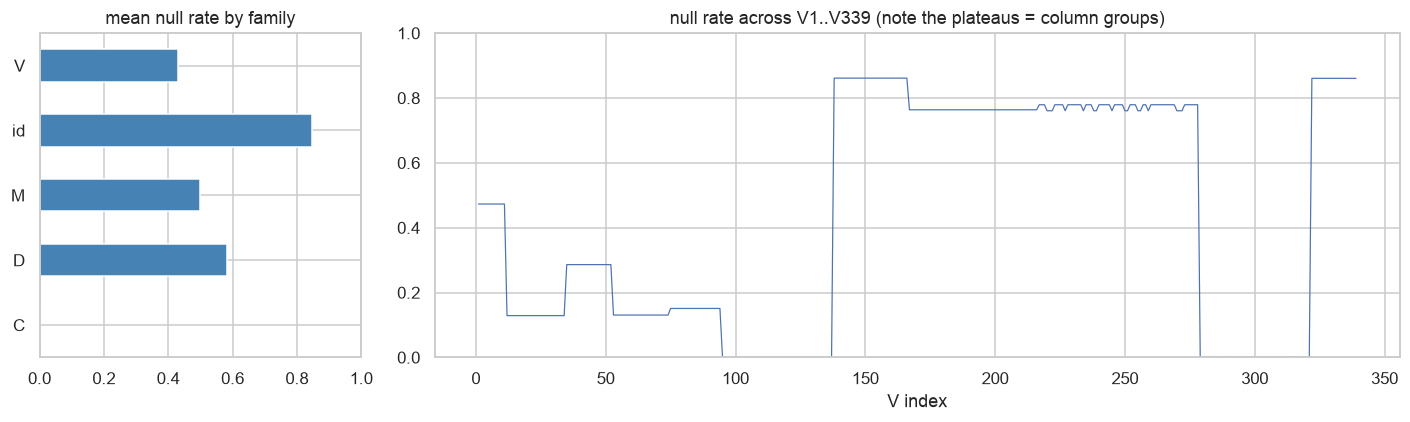

In [3]:
fam = {"C": [f"c{i}" for i in range(1,15)], "D": [f"d{i}" for i in range(1,16)], "M": [f"m{i}" for i in range(1,10)],
       "id": [c for c in df.columns if c.startswith("id_")], "V": [c for c in df.columns if c.startswith("v") and c[1:].isdigit()]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 3]})
rates = pd.Series({k: df[v].isna().mean().mean() for k, v in fam.items()})
rates.plot.barh(ax=axes[0], color="steelblue"); axes[0].set(title="mean null rate by family", xlim=(0, 1))
vnull = df[fam["V"]].isna().mean()
axes[1].plot(range(1, 340), vnull.values, lw=0.8); axes[1].set(title="null rate across V1..V339 (note the plateaus = column groups)", xlabel="V index", ylim=(0, 1))
plt.tight_layout()

## Identity coverage and product mix

Only a quarter of transactions carry an identity row. Fraud is concentrated in the ones that do, and in specific product codes, which is why `has_identity` and `product_cd` matter even before any engineering.

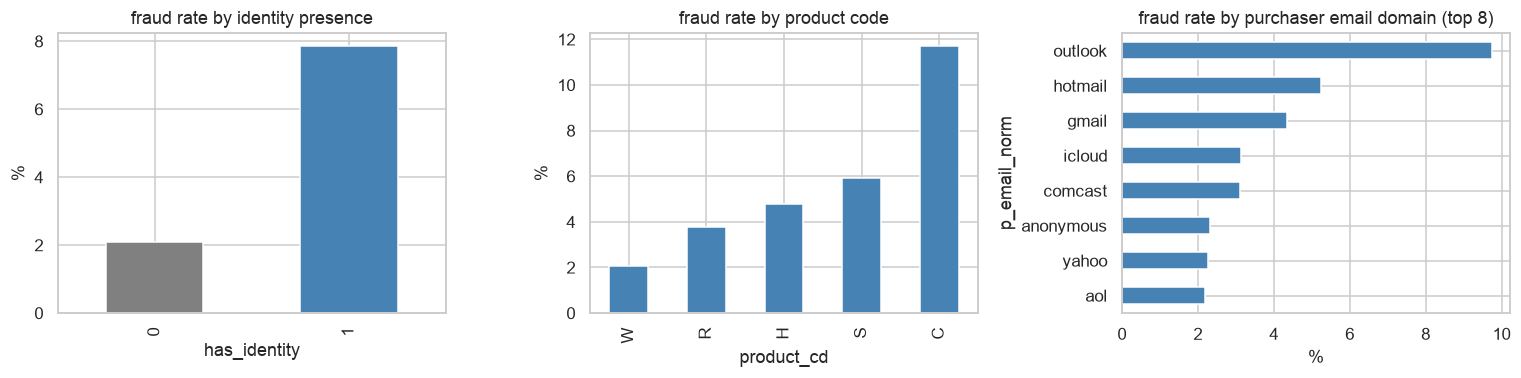

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
df.groupby("has_identity")["is_fraud"].mean().mul(100).plot.bar(ax=axes[0], color=["gray", "steelblue"]); axes[0].set(title="fraud rate by identity presence", ylabel="%")
df.groupby("product_cd")["is_fraud"].agg(["mean", "size"]).sort_values("mean").assign(mean=lambda x: x["mean"]*100)["mean"].plot.bar(ax=axes[1], color="steelblue"); axes[1].set(title="fraud rate by product code", ylabel="%")
top = df["p_email_norm"].value_counts().head(8).index
df[df.p_email_norm.isin(top)].groupby("p_email_norm")["is_fraud"].mean().mul(100).sort_values().plot.barh(ax=axes[2], color="steelblue"); axes[2].set(title="fraud rate by purchaser email domain (top 8)", xlabel="%")
plt.tight_layout()

## Amount: log scale, and the cents signal

Fraudulent amounts are larger on average, but the more surprising signal is the *cents* part: legitimate purchases cluster on round numbers and tax-driven fractions, fraud less so. `amt_cents` is derived at the silver layer for this reason.

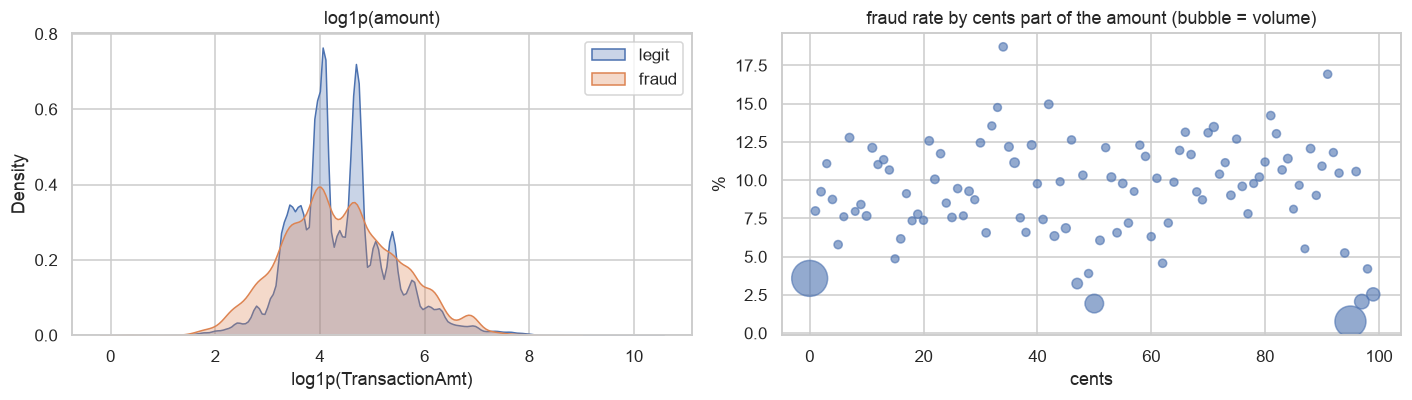

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for lab, name in ((0, "legit"), (1, "fraud")):
    sns.kdeplot(np.log1p(df.loc[df.is_fraud == lab, "transaction_amt"]), ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set(title="log1p(amount)", xlabel="log1p(TransactionAmt)"); axes[0].legend()
cents = df.groupby("amt_cents")["is_fraud"].agg(["mean", "size"]).query("size > 500")
axes[1].scatter(cents.index, cents["mean"]*100, s=np.sqrt(cents["size"]), alpha=0.6)
axes[1].set(title="fraud rate by cents part of the amount (bubble = volume)", xlabel="cents", ylabel="%")
plt.tight_layout()

## The engineered velocity features separate the classes

These are the `vel_*` and `card_*` columns from `feat.fct_velocity`, computed strictly from each card's *earlier* transactions.

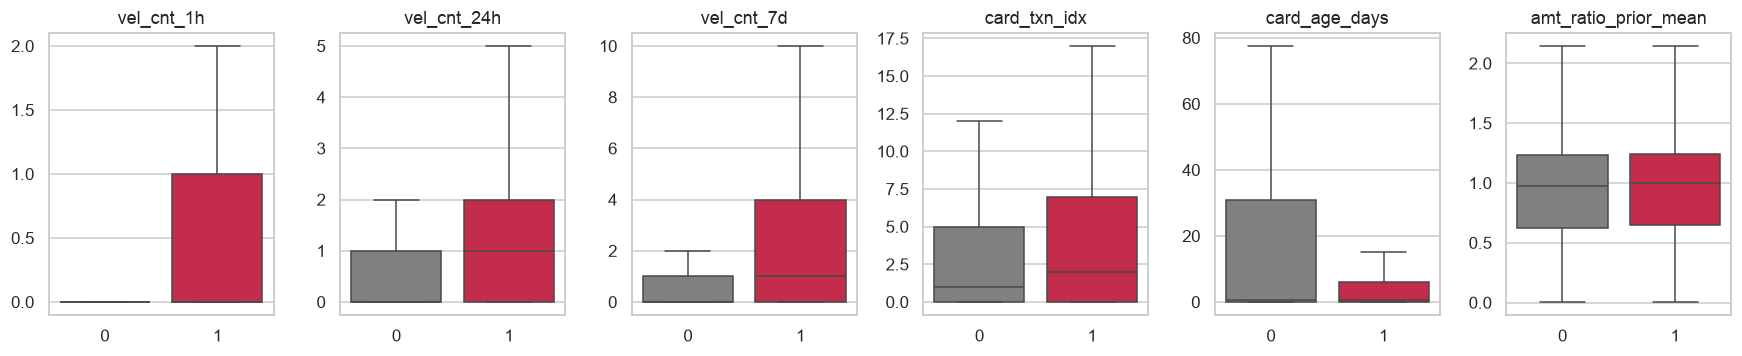

In [6]:
cols = ["vel_cnt_1h", "vel_cnt_24h", "vel_cnt_7d", "card_txn_idx", "card_age_days", "amt_ratio_prior_mean"]
fig, axes = plt.subplots(1, len(cols), figsize=(16, 3.4))
for ax, c in zip(axes, cols):
    d = df[[c, "is_fraud"]].dropna()
    q = d[c].quantile(0.99)
    sns.boxplot(data=d[d[c] <= q], x="is_fraud", y=c, ax=ax, showfliers=False, palette=["gray", "crimson"])
    ax.set(title=c, xlabel="", ylabel="")
plt.tight_layout()